# 향수 피처 관계 및 유사도 설명력 분석

## 1. 분석 목적

이번 분석의 목적은 추천 피처 후보가 실제 데이터에서 의미 있는 관계를 가지는지 확인하는 것입니다.

확인할 핵심 질문:

1. 특정 Note는 특정 Accord와 실제로 강하게 연결되는가?
2. Accord는 Season / Daypart와 실제 관계를 가지는가?
3. Accord가 비슷한 향수는 실제 사용자들도 비슷한 향이라고 평가하는가?
4. Notes가 비슷한 향수는 실제 사용자들도 비슷한 향이라고 평가하는가?
5. 어떤 피처가 향수 유사도를 가장 잘 설명하는가?

이번 단계에서는 추천 모델을 만들거나 가중치를 최적화하지 않습니다. Golden Set도 생성하지 않으며, 상관계수·Positive/Negative 차이·ROC-AUC 같은 효과 크기를 탐색합니다.

## 2. 데이터 로드 및 공통 전처리

perfumes.jsonl을 한 줄씩 읽어 필요한 정보만 수집합니다. 전체 JSONL을 DataFrame으로 변환하지 않으며, 큰 숫자 목록은 메모리 사용량이 작은 typed array에 저장합니다.

Note는 top, middle, base, flat 위치별 ID를 별도로 유지하면서 기본 유사도용 union set도 함께 만듭니다. 이 셀은 약 500MB의 JSONL을 파싱하고 관계 데이터를 수집하므로 실행 시간이 오래 걸릴 수 있습니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
import json
import pathlib
import collections
import array

work_dir = pathlib.Path.cwd()
jsonl_path = work_dir / "perfumes.jsonl"
csv_path = work_dir / "perfumes.csv"
schema_path = work_dir / "SCHEMA.md"

for path in [jsonl_path, csv_path, schema_path]:
    print(
        f"{path.name}: 존재={path.is_file()}, "
        f"크기={path.stat().st_size / (1024 ** 2):.2f} MB"
    )

perfumes.jsonl: 존재=True, 크기=485.94 MB
perfumes.csv: 존재=True, 크기=121.43 MB
SCHEMA.md: 존재=True, 크기=0.01 MB


### JSONL 1회 스트리밍

향수별 Accord, 위치별 Note와 union Note, Season/Daypart 비율 계산에 필요한 값, people을 수집합니다. reminds_me_of 관계는 source ID, target ID, up/down votes를 32비트 정수 배열에 임시 저장합니다.

원본 aggregate가 없으면 합계에는 -1, 비율에는 NaN을 사용해 실제 0표와 결측을 구분합니다.

In [2]:
perfume_ids = array.array("i")
people_by_perfume = array.array("i")
season_totals = array.array("i")
daypart_totals = array.array("i")

winter_shares = array.array("f")
spring_shares = array.array("f")
summer_shares = array.array("f")
autumn_shares = array.array("f")
day_shares = array.array("f")
night_shares = array.array("f")

accord_to_index = {}
note_to_index = {}
accord_entries_by_perfume = []
note_sets_by_perfume = []
note_positions_by_perfume = []
note_counts_per_perfume = array.array("I")

accord_support_counts = collections.Counter()
note_support_counts = collections.Counter()

relation_source_ids = array.array("i")
relation_target_ids = array.array("i")
relation_up_votes = array.array("i")
relation_down_votes = array.array("i")

with jsonl_path.open("r", encoding="utf-8") as file:
    for line in file:
        if not line.strip():
            continue

        record = json.loads(line)
        perfume_id = int(record["id"])
        perfume_ids.append(perfume_id)

        people = record.get("people")
        people_by_perfume.append(int(people) if people is not None else -1)

        # Accord 이름을 정수 ID로 치환해 향수별 sparse entry로 보관
        accord_strength_by_index = {}
        for item in record.get("accords") or []:
            accord_name = item.get("name")
            strength = item.get("strength")
            if not accord_name or strength is None:
                continue
            accord_index = accord_to_index.setdefault(
                accord_name, len(accord_to_index)
            )
            accord_strength_by_index[accord_index] = float(strength)

        accord_entries = tuple(accord_strength_by_index.items())
        accord_entries_by_perfume.append(accord_entries)
        accord_support_counts.update(accord_strength_by_index.keys())

        # 위치 정보는 유지하고, 기본 비교용으로 모든 위치의 union set 생성
        notes = record.get("notes") or {}
        tiered = notes.get("tiered") or {}
        note_name_groups = [
            {item.get("name") for item in tiered.get("top") or [] if item.get("name")},
            {item.get("name") for item in tiered.get("middle") or [] if item.get("name")},
            {item.get("name") for item in tiered.get("base") or [] if item.get("name")},
            {item.get("name") for item in notes.get("flat") or [] if item.get("name")},
        ]

        position_ids = []
        for names in note_name_groups:
            ids = tuple(
                note_to_index.setdefault(name, len(note_to_index))
                for name in sorted(names)
            )
            position_ids.append(ids)

        note_union = frozenset(
            note_index
            for position in position_ids
            for note_index in position
        )
        note_positions_by_perfume.append(tuple(position_ids))
        note_sets_by_perfume.append(note_union)
        note_counts_per_perfume.append(len(note_union))
        note_support_counts.update(note_union)

        # Season shares
        seasons = record.get("seasons")
        if not seasons:
            season_totals.append(-1)
            season_share_values = [np.nan] * 4
        else:
            season_values = [
                seasons.get("winter", 0),
                seasons.get("spring", 0),
                seasons.get("summer", 0),
                seasons.get("autumn", 0),
            ]
            season_total = sum(season_values)
            season_totals.append(season_total)
            season_share_values = (
                [value / season_total for value in season_values]
                if season_total > 0
                else [np.nan] * 4
            )

        winter_shares.append(season_share_values[0])
        spring_shares.append(season_share_values[1])
        summer_shares.append(season_share_values[2])
        autumn_shares.append(season_share_values[3])

        # Daypart shares
        daypart = record.get("daypart")
        if not daypart:
            daypart_totals.append(-1)
            daypart_share_values = [np.nan] * 2
        else:
            daypart_values = [daypart.get("day", 0), daypart.get("night", 0)]
            daypart_total = sum(daypart_values)
            daypart_totals.append(daypart_total)
            daypart_share_values = (
                [value / daypart_total for value in daypart_values]
                if daypart_total > 0
                else [np.nan] * 2
            )

        day_shares.append(daypart_share_values[0])
        night_shares.append(daypart_share_values[1])

        # Directed reminds_me_of 관계
        reminds_me_of = (
            (record.get("similar") or {}).get("reminds_me_of") or []
        )
        for relation in reminds_me_of:
            target_id = relation.get("id")
            up_votes = relation.get("up_votes")
            down_votes = relation.get("down_votes")

            relation_source_ids.append(perfume_id)
            relation_target_ids.append(
                int(target_id) if target_id is not None else -1
            )
            relation_up_votes.append(
                int(up_votes) if up_votes is not None else -1
            )
            relation_down_votes.append(
                int(down_votes) if down_votes is not None else -1
            )

accord_names = [None] * len(accord_to_index)
for name, index in accord_to_index.items():
    accord_names[index] = name

note_names = [None] * len(note_to_index)
for name, index in note_to_index.items():
    note_names[index] = name

id_to_row = {
    perfume_id: row
    for row, perfume_id in enumerate(perfume_ids)
}

total_perfumes = len(perfume_ids)

print(f"향수 수: {total_perfumes:,}")
print(f"관측된 고유 Accord 수: {len(accord_names):,}")
print(f"관측된 고유 Note 수: {len(note_names):,}")
print(f"수집한 directed relation 수: {len(relation_source_ids):,}")

향수 수: 131,930
관측된 고유 Accord 수: 92
관측된 고유 Note 수: 2,523
수집한 directed relation 수: 692,729


## 3. Note 기본 분포 확인

Note가 실제로 존재하는 향수의 규모, 향수당 Note 개수, 자주 등장하는 Note를 확인합니다. 동일 향수 안에서 같은 이름이 여러 위치에 있으면 union set에서는 한 번만 셉니다.

In [3]:
note_count_series = pd.Series(
    np.asarray(note_counts_per_perfume),
    name="note_count",
)
note_present_count = int((note_count_series > 0).sum())

note_overview = pd.Series({
    "전체 고유 Note 종류 수": len(note_names),
    "Note 보유 향수 수": note_present_count,
    "Note 보유 비율": note_present_count / total_perfumes,
    "향수당 Note 평균": note_count_series.mean(),
    "향수당 Note 중앙값": note_count_series.median(),
    "향수당 Note 25%": note_count_series.quantile(0.25),
    "향수당 Note 75%": note_count_series.quantile(0.75),
    "향수당 Note 최대": note_count_series.max(),
})
note_overview.to_frame("값")

,값
전체 고유 Note 종류 수,2523.000000
Note 보유 향수 수,129388.000000
Note 보유 비율,0.980732
향수당 Note 평균,8.275684
향수당 Note 중앙값,8.000000
향수당 Note 25%,5.000000
향수당 Note 75%,10.000000
향수당 Note 최대,65.000000


### 가장 많이 등장하는 Note TOP 30

각 Note가 포함된 향수 수와 전체 향수 대비 비율을 계산합니다.

In [4]:
top_30_notes = pd.DataFrame(
    [
        (note_names[note_index], count)
        for note_index, count in note_support_counts.most_common(30)
    ],
    columns=["note", "등장 향수 수"],
)
top_30_notes["전체 향수 대비 비율"] = (
    top_30_notes["등장 향수 수"] / total_perfumes
)
top_30_notes

,note,등장 향수 수,전체 향수 대비 비율
0,Musk,49244,0.373259
1,Amber,36671,0.277958
2,Bergamot,36337,0.275426
3,Vanilla,35628,0.270052
4,Sandalwood,34292,0.259926
5,Jasmine,33686,0.255332
6,Patchouli,32473,0.246138
7,Rose,27804,0.210748
8,Cedar,22305,0.169067
9,Vetiver,17674,0.133965


### TOP 20 Note 빈도 시각화

가장 자주 등장하는 20개 Note의 향수 수를 bar chart로 비교합니다.

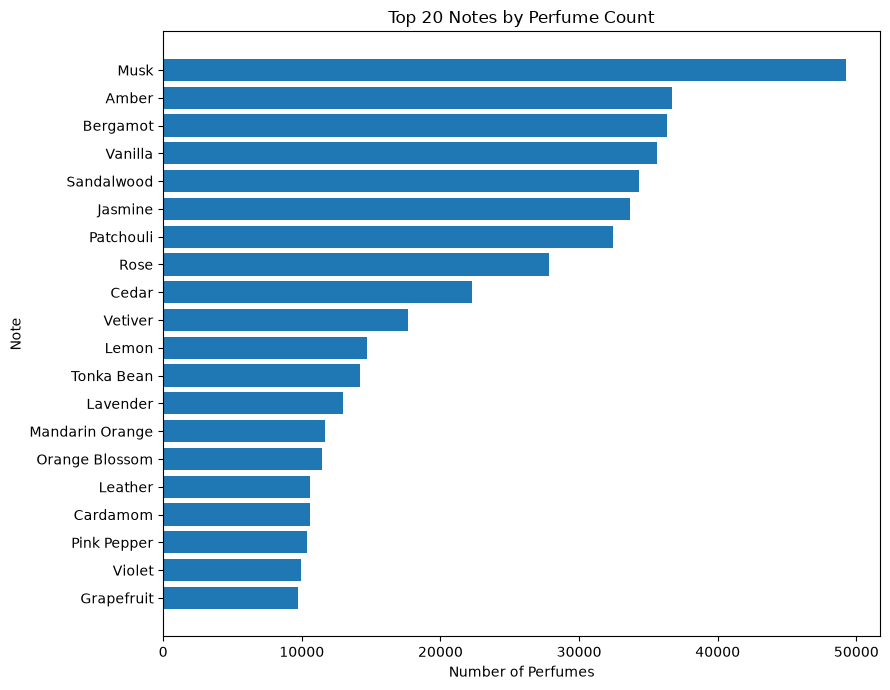

In [5]:
top_20_notes_for_plot = (
    top_30_notes.head(20)
    .sort_values("등장 향수 수")
)

plt.figure(figsize=(9, 7))
plt.barh(
    top_20_notes_for_plot["note"],
    top_20_notes_for_plot["등장 향수 수"],
)
plt.title("Top 20 Notes by Perfume Count")
plt.xlabel("Number of Perfumes")
plt.ylabel("Note")
plt.tight_layout()
plt.show()

## 4. Notes → Accords 관계 분석

희귀 Note의 노이즈를 줄이기 위해 등장 빈도 TOP 100 Note만 탐색합니다. 이는 EDA 범위를 제한하는 임시 기준이며 최종 feature selection 기준이 아닙니다.

각 Note-Accord 조합에 대해 support, 동시 등장 수, 조건부 확률, 전체 Accord 확률, lift와 평균 strength를 계산합니다. lift는 반드시 cooccurrence_count와 함께 해석합니다. 이 셀은 모든 향수의 TOP 100 Note × Accord 조합을 집계하므로 시간이 걸릴 수 있습니다.

In [6]:
top_100_note_indices = [
    note_index
    for note_index, _ in note_support_counts.most_common(100)
]
top_100_note_set = set(top_100_note_indices)

note_accord_cooccurrence = collections.defaultdict(int)
note_accord_strength_sum = collections.defaultdict(float)

for note_set, accord_entries in zip(
    note_sets_by_perfume,
    accord_entries_by_perfume,
):
    selected_notes = note_set.intersection(top_100_note_set)
    if not selected_notes or not accord_entries:
        continue

    for note_index in selected_notes:
        for accord_index, strength in accord_entries:
            pair = (note_index, accord_index)
            note_accord_cooccurrence[pair] += 1
            note_accord_strength_sum[pair] += strength

note_accord_rows = []
for (note_index, accord_index), cooccurrence_count in (
    note_accord_cooccurrence.items()
):
    note_support = note_support_counts[note_index]
    accord_support = accord_support_counts[accord_index]
    probability_accord_given_note = cooccurrence_count / note_support
    probability_accord = accord_support / total_perfumes

    if probability_accord == 0:
        continue

    note_accord_rows.append({
        "note": note_names[note_index],
        "accord": accord_names[accord_index],
        "note_support": note_support,
        "accord_support": accord_support,
        "cooccurrence_count": cooccurrence_count,
        "p_accord_given_note": probability_accord_given_note,
        "p_accord": probability_accord,
        "lift": probability_accord_given_note / probability_accord,
        "mean_accord_strength": (
            note_accord_strength_sum[(note_index, accord_index)]
            / cooccurrence_count
        ),
    })

note_accord_df = pd.DataFrame(note_accord_rows)
print(f"분석한 TOP Note 수: {len(top_100_note_indices):,}")
print(f"관측된 Note-Accord 조합 수: {len(note_accord_df):,}")

분석한 TOP Note 수: 100
관측된 Note-Accord 조합 수: 7,576


### Cooccurrence threshold별 분석 가능한 관계 규모

cooccurrence_count 10, 50, 100, 500 이상에서 남는 관계 수를 모두 보여줍니다. 특정 threshold를 최종 기준으로 선택하지 않습니다.

In [7]:
cooccurrence_thresholds = [10, 50, 100, 500]
cooccurrence_scale = pd.DataFrame([
    {
        "threshold": f"cooccurrence_count >= {threshold}",
        "관계 수": int(
            (note_accord_df["cooccurrence_count"] >= threshold).sum()
        ),
        "전체 조합 대비 비율": (
            (note_accord_df["cooccurrence_count"] >= threshold).sum()
            / len(note_accord_df)
        ),
    }
    for threshold in cooccurrence_thresholds
])
cooccurrence_scale

,threshold,관계 수,전체 조합 대비 비율
0,cooccurrence_count >= 10,6108,0.806230
1,cooccurrence_count >= 50,4794,0.632788
2,cooccurrence_count >= 100,4020,0.530623
3,cooccurrence_count >= 500,2206,0.291183


### Threshold별 lift 상위 Note-Accord 관계

임의의 한 기준을 고정하지 않기 위해 각 탐색 threshold에서 lift가 높은 관계 TOP 30을 각각 출력합니다. cooccurrence_count와 평균 Accord strength도 함께 표시합니다.

In [8]:
lift_columns = [
    "note", "accord", "note_support", "accord_support",
    "cooccurrence_count", "p_accord_given_note", "p_accord",
    "lift", "mean_accord_strength",
]

for threshold in cooccurrence_thresholds:
    top_lift = (
        note_accord_df[
            note_accord_df["cooccurrence_count"] >= threshold
        ]
        .sort_values(
            ["lift", "cooccurrence_count"],
            ascending=[False, False],
        )
        .head(30)[lift_columns]
        .round(3)
    )
    print("=" * 90)
    print(f"cooccurrence_count >= {threshold}: lift TOP 30")
    print(top_lift.to_string(index=False))

cooccurrence_count >= 10: lift TOP 30
          note        accord  note_support  accord_support  cooccurrence_count  p_accord_given_note  p_accord   lift  mean_accord_strength
        Coffee        coffee          2469            1815                1655                0.670     0.014 48.724                58.269
       Coconut       coconut          3886            3269                2727                0.702     0.025 28.321                59.022
         Honey         honey          3974            3467                2784                0.701     0.026 26.658                58.871
        Almond        almond          2713            3438                1867                0.688     0.026 26.408                59.959
     Sea Notes        marine          2183            4326                1815                0.831     0.033 25.356                67.156
       Caramel       caramel          4734            4008                3484                0.736     0.030 24.225            

### 대표 Note별 관련 Accord TOP 5

요청된 대표 Note가 TOP 100에 포함된 경우에만 출력합니다. 극소수 동시 등장으로 인한 과도한 lift를 줄이기 위해 탐색용 최소 cooccurrence_count 10을 적용하되, 이는 최종 기준이 아닙니다.

In [9]:
representative_notes = [
    "Bergamot", "Vanilla", "Rose", "Jasmine",
    "Musk", "Lemon", "Cedar", "Patchouli",
]
top_100_note_names = {
    note_names[index] for index in top_100_note_indices
}

for note_name in representative_notes:
    if note_name not in top_100_note_names:
        continue

    related_accords = (
        note_accord_df[
            (note_accord_df["note"] == note_name)
            & (note_accord_df["cooccurrence_count"] >= 10)
        ]
        .sort_values(
            ["lift", "cooccurrence_count"],
            ascending=[False, False],
        )
        .head(5)[
            [
                "note", "accord", "cooccurrence_count",
                "p_accord_given_note", "lift",
                "mean_accord_strength",
            ]
        ]
        .round(3)
    )
    print("=" * 80)
    print(f"{note_name}: related Accord TOP 5")
    print(related_accords.to_string(index=False))

Bergamot: related Accord TOP 5
    note      accord  cooccurrence_count  p_accord_given_note  lift  mean_accord_strength
Bergamot      citrus               27031                0.744 1.637                72.087
Bergamot fresh spicy               19324                0.532 1.484                54.636
Bergamot    lavender                3393                0.093 1.478                50.908
Bergamot    aromatic               20820                0.573 1.384                59.366
Bergamot       mossy                2304                0.063 1.355                47.055
Vanilla: related Accord TOP 5
   note    accord  cooccurrence_count  p_accord_given_note  lift  mean_accord_strength
Vanilla   vanilla               25290                0.710 2.710                63.466
Vanilla   caramel                2268                0.064 2.095                53.870
Vanilla    almond                1656                0.046 1.784                54.523
Vanilla chocolate                 722              

## 5. Accord → Season 관계 분석

향수마다 커뮤니티 투표량이 다르므로 raw count 대신 각 계절의 vote share를 사용합니다. season_total이 0이거나 원본 데이터가 없으면 분석에서 제외합니다.

먼저 threshold별 규모를 확인한 뒤, 탐색용으로 season_total >= 20만 사용합니다. 20은 최종 추천 기준이 아니라 이번 EDA를 위한 임시 기준입니다.

In [10]:
number_of_accords = len(accord_names)
accord_matrix = np.zeros(
    (total_perfumes, number_of_accords),
    dtype=np.float32,
)

for row, accord_entries in enumerate(accord_entries_by_perfume):
    for accord_index, strength in accord_entries:
        accord_matrix[row, accord_index] = strength

# Dense matrix를 만든 뒤 중복 sparse 저장 구조는 해제
del accord_entries_by_perfume

season_total_values = np.asarray(season_totals)
season_share_matrix = np.column_stack([
    np.asarray(winter_shares),
    np.asarray(spring_shares),
    np.asarray(summer_shares),
    np.asarray(autumn_shares),
]).astype(np.float32, copy=False)
season_names = ["winter", "spring", "summer", "autumn"]

season_thresholds = [1, 10, 20, 50, 100]
season_threshold_summary = pd.DataFrame([
    {
        "threshold": f"season_total >= {threshold}",
        "향수 수": int((season_total_values >= threshold).sum()),
        "전체 향수 대비 비율": (
            (season_total_values >= threshold).sum() / total_perfumes
        ),
    }
    for threshold in season_thresholds
])

print(
    f"Accord vector 차원: {number_of_accords} "
    f"(데이터에서 관측된 전체 Accord 종류)"
)
season_threshold_summary

Accord vector 차원: 92 (데이터에서 관측된 전체 Accord 종류)


,threshold,향수 수,전체 향수 대비 비율
0,season_total >= 1,111351,0.844016
1,season_total >= 10,74601,0.565459
2,season_total >= 20,57533,0.436087
3,season_total >= 50,37880,0.287122
4,season_total >= 100,25515,0.193398


### Accord strength와 Season share의 Spearman correlation

season_total >= 20인 향수에서 각 Accord strength와 네 계절 share의 순위 상관을 계산합니다. 상관계수 크기를 중심으로 해석하며, 표본이 커서 작은 효과도 통계적으로 유의할 수 있다는 점에 유의합니다.

In [11]:
def spearman_against_targets(
    feature_matrix,
    target_matrix,
    row_mask,
    feature_names,
    target_names,
):
    feature_frame = pd.DataFrame(
        feature_matrix[row_mask],
        columns=feature_names,
    )
    result = {}
    for target_index, target_name in enumerate(target_names):
        target_series = pd.Series(
            target_matrix[row_mask, target_index]
        )
        result[target_name] = feature_frame.corrwith(
            target_series,
            method="spearman",
        )
    return pd.DataFrame(result)

season_analysis_mask = (
    (season_total_values >= 20)
    & np.isfinite(season_share_matrix).all(axis=1)
)

season_correlations = spearman_against_targets(
    accord_matrix,
    season_share_matrix,
    season_analysis_mask,
    accord_names,
    season_names,
)

print(f"season_total >= 20 분석 향수 수: {season_analysis_mask.sum():,}")

season_total >= 20 분석 향수 수: 57,533


### 계절별 양·음의 상관 TOP 10

각 계절마다 양의 상관이 큰 Accord와 음의 상관이 큰 Accord를 소수점 셋째 자리까지 출력합니다.

In [12]:
for season_name in season_names:
    correlations = season_correlations[season_name].dropna()
    positive_top_10 = correlations.nlargest(10).round(3)
    negative_top_10 = correlations.nsmallest(10).round(3)

    print("=" * 70)
    print(f"{season_name.upper()} - positive correlation TOP 10")
    print(positive_top_10.to_string())
    print()
    print(f"{season_name.upper()} - negative correlation TOP 10")
    print(negative_top_10.to_string())

WINTER - positive correlation TOP 10
warm spicy    0.440
amber         0.350
vanilla       0.300
balsamic      0.281
oud           0.244
leather       0.225
smoky         0.200
cinnamon      0.183
tobacco       0.179
woody         0.177

WINTER - negative correlation TOP 10
citrus         -0.404
fresh          -0.354
green          -0.323
aquatic        -0.235
floral         -0.220
marine         -0.173
white floral   -0.169
ozonic         -0.164
fruity         -0.162
aromatic       -0.155
SPRING - positive correlation TOP 10
fresh           0.336
citrus          0.323
green           0.308
floral          0.276
white floral    0.203
aquatic         0.186
fruity          0.154
ozonic          0.143
musky           0.107
aromatic        0.104

SPRING - negative correlation TOP 10
warm spicy   -0.419
amber        -0.330
vanilla      -0.275
balsamic     -0.271
oud          -0.219
leather      -0.204
smoky        -0.198
cinnamon     -0.181
woody        -0.172
tobacco      -0.168
SUMMER - p

### TOP 20 빈도 Accord × Season correlation matrix

가장 많은 향수에 등장한 Accord 20개의 계절 상관계수를 imshow로 시각화합니다.

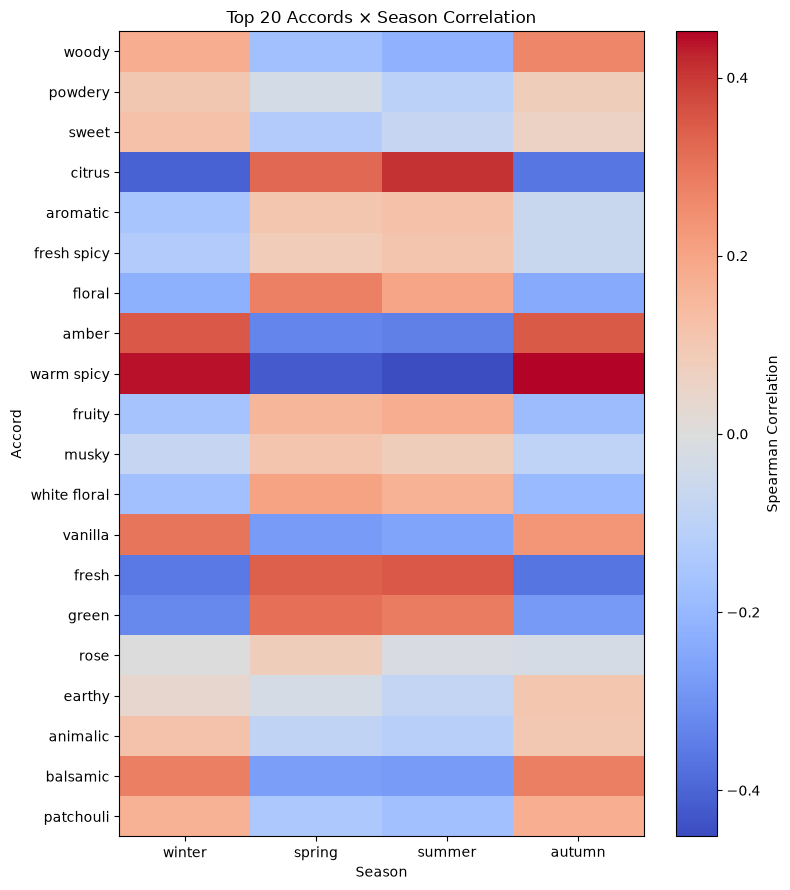

In [13]:
top_20_accord_indices = [
    accord_index
    for accord_index, _ in accord_support_counts.most_common(20)
]
top_20_accord_names = [
    accord_names[index] for index in top_20_accord_indices
]
season_plot_values = season_correlations.loc[
    top_20_accord_names,
    season_names,
].to_numpy()

correlation_limit = np.nanmax(np.abs(season_plot_values))

plt.figure(figsize=(8, 9))
image = plt.imshow(
    season_plot_values,
    aspect="auto",
    cmap="coolwarm",
    vmin=-correlation_limit,
    vmax=correlation_limit,
)
plt.colorbar(image, label="Spearman Correlation")
plt.xticks(range(len(season_names)), season_names)
plt.yticks(range(len(top_20_accord_names)), top_20_accord_names)
plt.title("Top 20 Accords × Season Correlation")
plt.xlabel("Season")
plt.ylabel("Accord")
plt.tight_layout()
plt.show()

## 6. Accord → Day / Night 관계 분석

day와 night의 raw vote count 대신 daypart_total 내 share를 사용합니다. 먼저 threshold별 규모를 확인하고, 관계 분석에서는 EDA용 임시 기준인 daypart_total >= 20을 사용합니다. 이 값은 최종 추천 기준이 아닙니다.

In [14]:
daypart_total_values = np.asarray(daypart_totals)
daypart_share_matrix = np.column_stack([
    np.asarray(day_shares),
    np.asarray(night_shares),
]).astype(np.float32, copy=False)
daypart_names = ["day", "night"]

daypart_thresholds = [1, 10, 20, 50, 100]
daypart_threshold_summary = pd.DataFrame([
    {
        "threshold": f"daypart_total >= {threshold}",
        "향수 수": int((daypart_total_values >= threshold).sum()),
        "전체 향수 대비 비율": (
            (daypart_total_values >= threshold).sum() / total_perfumes
        ),
    }
    for threshold in daypart_thresholds
])
daypart_threshold_summary

,threshold,향수 수,전체 향수 대비 비율
0,daypart_total >= 1,109559,0.830433
1,daypart_total >= 10,60416,0.457940
2,daypart_total >= 20,44421,0.336701
3,daypart_total >= 50,27080,0.205260
4,daypart_total >= 100,17113,0.129713


### Accord strength와 Day/Night share의 Spearman correlation

daypart_total >= 20인 향수에서 모든 Accord strength와 day/night share의 순위 상관을 계산합니다.

In [15]:
daypart_analysis_mask = (
    (daypart_total_values >= 20)
    & np.isfinite(daypart_share_matrix).all(axis=1)
)

daypart_correlations = spearman_against_targets(
    accord_matrix,
    daypart_share_matrix,
    daypart_analysis_mask,
    accord_names,
    daypart_names,
)

print(
    f"daypart_total >= 20 분석 향수 수: "
    f"{daypart_analysis_mask.sum():,}"
)

c:\Users\dyftj\OneDrive\바탕 화면\향수_데이터\venv\Lib\site-packages\pandas\core\nanops.py:1673: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


daypart_total >= 20 분석 향수 수: 44,421


### Day 및 Night와 양의 상관이 큰 Accord TOP 15

각 사용 시간대 share와 양의 방향으로 가장 크게 연결되는 Accord를 출력합니다.

In [16]:
for daypart_name in daypart_names:
    positive_top_15 = (
        daypart_correlations[daypart_name]
        .dropna()
        .nlargest(15)
        .round(3)
    )
    print("=" * 70)
    print(f"{daypart_name.upper()} - positive correlation TOP 15")
    print(positive_top_15.to_string())

DAY - positive correlation TOP 15
fresh           0.366
citrus          0.349
green           0.304
floral          0.261
aquatic         0.228
fruity          0.176
white floral    0.166
ozonic          0.154
tropical        0.139
marine          0.122
salty           0.093
musky           0.090
herbal          0.075
soapy           0.070
lactonic        0.067
NIGHT - positive correlation TOP 15
warm spicy    0.450
amber         0.383
oud           0.271
leather       0.252
balsamic      0.243
woody         0.240
vanilla       0.225
smoky         0.209
patchouli     0.188
tobacco       0.186
cinnamon      0.155
animalic      0.148
coffee        0.114
metallic      0.111
cacao         0.108


## 7. Reminds Me Of 관계 데이터 정리

directed 관계를 먼저 확인한 뒤 (min(id), max(id)) 형태의 unordered pair로 변환합니다. 같은 unordered pair의 up/down votes는 합산합니다.

대규모 groupby가 수행되므로 이 셀은 실행 시간이 오래 걸리고 일시적으로 추가 메모리를 사용할 수 있습니다.

In [17]:
directed_relations = pd.DataFrame({
    "source_id": np.frombuffer(
        relation_source_ids,
        dtype=np.int32,
    ),
    "target_id": np.frombuffer(
        relation_target_ids,
        dtype=np.int32,
    ),
    "up_votes": np.frombuffer(
        relation_up_votes,
        dtype=np.int32,
    ),
    "down_votes": np.frombuffer(
        relation_down_votes,
        dtype=np.int32,
    ),
})

directed_relation_count = len(directed_relations)
valid_directed_mask = (
    (directed_relations["source_id"] >= 0)
    & (directed_relations["target_id"] >= 0)
    & (directed_relations["up_votes"] >= 0)
    & (directed_relations["down_votes"] >= 0)
)
valid_directed = directed_relations.loc[valid_directed_mask].copy()
valid_directed["total_votes"] = (
    valid_directed["up_votes"] + valid_directed["down_votes"]
)
valid_directed["agree_ratio"] = np.where(
    valid_directed["total_votes"] > 0,
    valid_directed["up_votes"] / valid_directed["total_votes"],
    np.nan,
)

valid_directed["pair_low"] = np.minimum(
    valid_directed["source_id"],
    valid_directed["target_id"],
)
valid_directed["pair_high"] = np.maximum(
    valid_directed["source_id"],
    valid_directed["target_id"],
)
valid_directed["direction"] = (
    valid_directed["source_id"] == valid_directed["pair_low"]
).astype("int8")

unique_pair_directions = valid_directed[
    ["pair_low", "pair_high", "direction"]
].drop_duplicates()

direction_count_by_pair = (
    unique_pair_directions
    .groupby(["pair_low", "pair_high"], sort=False)
    .size()
)
reciprocal_pair_count = int((direction_count_by_pair == 2).sum())

pair_relations = (
    valid_directed
    .groupby(
        ["pair_low", "pair_high"],
        sort=False,
        as_index=False,
    )[["up_votes", "down_votes"]]
    .sum()
)
pair_relations["total_votes"] = (
    pair_relations["up_votes"] + pair_relations["down_votes"]
)
pair_relations["agree_ratio"] = np.where(
    pair_relations["total_votes"] > 0,
    pair_relations["up_votes"] / pair_relations["total_votes"],
    np.nan,
)

relation_structure_summary = pd.Series({
    "directed relation 수": directed_relation_count,
    "유효 directed relation 수": len(valid_directed),
    "unordered unique pair 수": len(pair_relations),
    "양방향으로 모두 존재하는 pair 수": reciprocal_pair_count,
    "유효하지 않은 ID/투표 관계 수": (
        directed_relation_count - len(valid_directed)
    ),
})
relation_structure_summary.to_frame("값")

,값
directed relation 수,692729
유효 directed relation 수,692729
unordered unique pair 수,487162
양방향으로 모두 존재하는 pair 수,205567
유효하지 않은 ID/투표 관계 수,0


### Directed 관계 임시 데이터 메모리 해제

unordered pair 집계가 끝났으므로 더 이상 필요하지 않은 directed DataFrame과 원시 typed array를 해제합니다. 계산 결과에는 영향을 주지 않습니다.

In [18]:
del directed_relations
del valid_directed
del unique_pair_directions
del direction_count_by_pair
del relation_source_ids
del relation_target_ids
del relation_up_votes
del relation_down_votes

print("Directed 관계 임시 데이터 메모리를 해제했습니다.")

Directed 관계 임시 데이터 메모리를 해제했습니다.


## 8. Positive / Negative 관계 규모 확인

Golden Set을 만들지 않고, 지정된 조건에 해당하는 unordered pair의 수만 확인합니다. Negative가 적더라도 threshold를 자동으로 바꾸지 않습니다.

In [19]:
positive_mask = (
    (pair_relations["total_votes"] >= 20)
    & (pair_relations["agree_ratio"] >= 0.8)
)
negative_mask = (
    (pair_relations["total_votes"] >= 20)
    & (pair_relations["agree_ratio"] <= 0.2)
)

positive_pair_count = int(positive_mask.sum())
negative_pair_count = int(negative_mask.sum())

pd.Series({
    "Positive 관계 수": positive_pair_count,
    "Negative 관계 수": negative_pair_count,
}).to_frame("값")

,값
Positive 관계 수,10770
Negative 관계 수,0


### Agree ratio threshold별 관계 수

total_votes >= 20인 unordered pair만 대상으로 요청된 agree ratio 기준별 개수를 비교합니다.

In [20]:
voted_pair_relations = pair_relations[
    pair_relations["total_votes"] >= 20
]

agree_ratio_threshold_summary = pd.DataFrame([
    {
        "조건": "agree_ratio <= 0.1",
        "관계 수": int(
            (voted_pair_relations["agree_ratio"] <= 0.1).sum()
        ),
    },
    {
        "조건": "agree_ratio <= 0.2",
        "관계 수": int(
            (voted_pair_relations["agree_ratio"] <= 0.2).sum()
        ),
    },
    {
        "조건": "agree_ratio <= 0.3",
        "관계 수": int(
            (voted_pair_relations["agree_ratio"] <= 0.3).sum()
        ),
    },
    {
        "조건": "agree_ratio >= 0.7",
        "관계 수": int(
            (voted_pair_relations["agree_ratio"] >= 0.7).sum()
        ),
    },
    {
        "조건": "agree_ratio >= 0.8",
        "관계 수": int(
            (voted_pair_relations["agree_ratio"] >= 0.8).sum()
        ),
    },
    {
        "조건": "agree_ratio >= 0.9",
        "관계 수": int(
            (voted_pair_relations["agree_ratio"] >= 0.9).sum()
        ),
    },
])
agree_ratio_threshold_summary

,조건,관계 수
0,agree_ratio <= 0.1,0
1,agree_ratio <= 0.2,0
2,agree_ratio <= 0.3,0
3,agree_ratio >= 0.7,20378
4,agree_ratio >= 0.8,10770
5,agree_ratio >= 0.9,3900


### 유사도 계산용 후보 pair 준비

Positive=1, Negative=0으로 표시하고 두 ID가 모두 현재 데이터셋에 있는 pair만 유사도 계산 대상으로 남깁니다. 전체 후보 수와 실제 계산 가능한 내부 pair 수를 구분합니다.

In [21]:
positive_pairs = pair_relations.loc[
    positive_mask,
    ["pair_low", "pair_high", "total_votes", "agree_ratio"],
].copy()
positive_pairs["label"] = 1

negative_pairs = pair_relations.loc[
    negative_mask,
    ["pair_low", "pair_high", "total_votes", "agree_ratio"],
].copy()
negative_pairs["label"] = 0

candidate_pairs = pd.concat(
    [positive_pairs, negative_pairs],
    ignore_index=True,
)
candidate_pairs["row_a"] = candidate_pairs["pair_low"].map(id_to_row)
candidate_pairs["row_b"] = candidate_pairs["pair_high"].map(id_to_row)

similarity_pairs = candidate_pairs.dropna(
    subset=["row_a", "row_b"]
).copy()
similarity_pairs["row_a"] = similarity_pairs["row_a"].astype("int32")
similarity_pairs["row_b"] = similarity_pairs["row_b"].astype("int32")

candidate_availability = pd.Series({
    "전체 Positive/Negative 후보 pair": len(candidate_pairs),
    "현재 데이터셋 내부의 유사도 계산 가능 pair": len(similarity_pairs),
    "dataset 밖 ID를 포함해 제외된 pair": (
        len(candidate_pairs) - len(similarity_pairs)
    ),
})
candidate_availability.to_frame("값")

,값
전체 Positive/Negative 후보 pair,10770
현재 데이터셋 내부의 유사도 계산 가능 pair,10770
dataset 밖 ID를 포함해 제외된 pair,0


### 전체 unordered 관계 테이블 메모리 해제

Positive/Negative 후보를 추출했으므로 전체 pair 관계 테이블을 해제합니다. 새로운 데이터 파일은 저장하지 않습니다.

In [22]:
del pair_relations
del voted_pair_relations
del positive_pairs
del negative_pairs
del candidate_pairs

print("전체 unordered 관계 임시 테이블을 해제했습니다.")

전체 unordered 관계 임시 테이블을 해제했습니다.


## 9. Accord Similarity 계산

각 향수를 관측된 전체 Accord 종류 차원의 strength vector로 표현합니다. 데이터에서 92개가 관측되면 92차원이 됩니다.

목록에 없는 Accord의 0은 '향에 완전히 존재하지 않는다'가 아니라 '주요 Accord 목록에 기록되지 않았다'는 뜻일 수 있습니다. 따라서 cosine similarity도 이 관측 한계를 갖습니다.

In [23]:
row_a = similarity_pairs["row_a"].to_numpy()
row_b = similarity_pairs["row_b"].to_numpy()

accord_norms = np.linalg.norm(accord_matrix, axis=1)
accord_denominator = accord_norms[row_a] * accord_norms[row_b]
accord_dot_product = np.einsum(
    "ij,ij->i",
    accord_matrix[row_a],
    accord_matrix[row_b],
)

accord_cosine = np.full(
    len(similarity_pairs),
    np.nan,
    dtype=np.float32,
)
np.divide(
    accord_dot_product,
    accord_denominator,
    out=accord_cosine,
    where=accord_denominator > 0,
)
similarity_pairs["accord_cosine"] = accord_cosine

def similarity_group_summary(data, score_column):
    rows = {}
    for label, label_name in [(1, "Positive"), (0, "Negative")]:
        values = data.loc[
            data["label"] == label,
            score_column,
        ].dropna()
        rows[label_name] = {
            "count": values.size,
            "mean": values.mean(),
            "median": values.median(),
            "25%": values.quantile(0.25),
            "75%": values.quantile(0.75),
        }
    return pd.DataFrame(rows).T

accord_similarity_summary = similarity_group_summary(
    similarity_pairs,
    "accord_cosine",
)
accord_similarity_summary

,count,mean,median,25%,75%
Positive,10664.0,0.728045,0.781355,0.608502,0.894387
Negative,0.0,NaN,NaN,NaN,NaN


### Positive / Negative Accord cosine 분포 비교

두 후보 집단의 Accord cosine similarity를 같은 그래프에 겹쳐 차이의 방향과 분포 형태를 확인합니다.

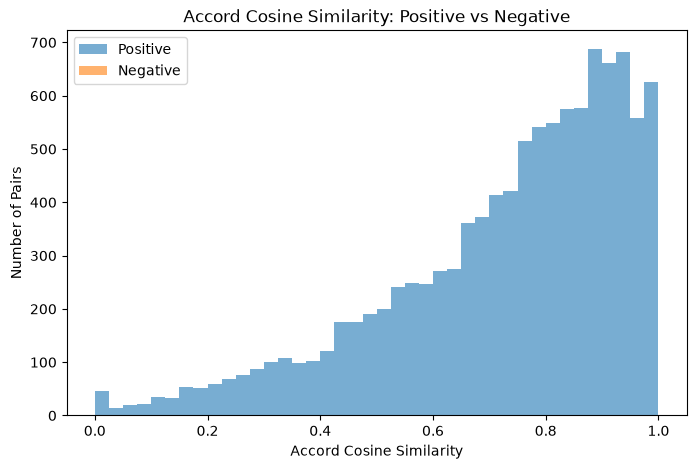

In [24]:
positive_accord = similarity_pairs.loc[
    similarity_pairs["label"] == 1,
    "accord_cosine",
].dropna()
negative_accord = similarity_pairs.loc[
    similarity_pairs["label"] == 0,
    "accord_cosine",
].dropna()

plt.figure(figsize=(8, 5))
plt.hist(
    positive_accord,
    bins=40,
    alpha=0.6,
    label="Positive",
)
plt.hist(
    negative_accord,
    bins=40,
    alpha=0.6,
    label="Negative",
)
plt.title("Accord Cosine Similarity: Positive vs Negative")
plt.xlabel("Accord Cosine Similarity")
plt.ylabel("Number of Pairs")
plt.legend()
plt.show()

## 10. Note Similarity 계산

향수별 위치 통합 note_set으로 Jaccard similarity를 계산합니다. 두 향수 모두 Note가 없으면 union이 비어 있으므로 NaN으로 처리합니다. Tier 위치 정보는 note_positions_by_perfume에 별도로 유지되어 있지만, 이번 기본 비교에서는 사용하지 않습니다.

In [25]:
def note_jaccard_similarity(row_index_a, row_index_b):
    notes_a = note_sets_by_perfume[row_index_a]
    notes_b = note_sets_by_perfume[row_index_b]
    union = notes_a | notes_b
    if not union:
        return np.nan
    return len(notes_a & notes_b) / len(union)

similarity_pairs["note_jaccard"] = [
    note_jaccard_similarity(index_a, index_b)
    for index_a, index_b in zip(row_a, row_b)
]

note_similarity_summary = similarity_group_summary(
    similarity_pairs,
    "note_jaccard",
)
note_similarity_summary

,count,mean,median,25%,75%
Positive,10769.0,0.332767,0.25,0.115385,0.5
Negative,0.0,NaN,NaN,NaN,NaN


### Positive / Negative Note Jaccard 분포 비교

두 후보 집단의 Note Jaccard similarity 분포를 같은 그래프에서 비교합니다.

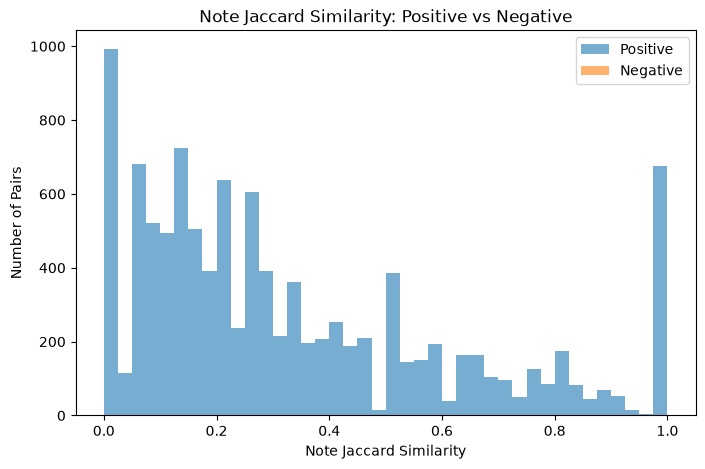

In [26]:
positive_note = similarity_pairs.loc[
    similarity_pairs["label"] == 1,
    "note_jaccard",
].dropna()
negative_note = similarity_pairs.loc[
    similarity_pairs["label"] == 0,
    "note_jaccard",
].dropna()

plt.figure(figsize=(8, 5))
plt.hist(
    positive_note,
    bins=40,
    alpha=0.6,
    label="Positive",
)
plt.hist(
    negative_note,
    bins=40,
    alpha=0.6,
    label="Negative",
)
plt.title("Note Jaccard Similarity: Positive vs Negative")
plt.xlabel("Note Jaccard Similarity")
plt.ylabel("Number of Pairs")
plt.legend()
plt.show()

## 11. 각 유사도 지표의 설명력 비교

머신러닝 모델을 학습하지 않고 Accord cosine과 Note Jaccard라는 단일 score가 Positive(1)와 Negative(0)를 얼마나 구분하는지만 ROC-AUC로 확인합니다.

이 AUC는 최종 추천 모델 성능이 아니라 해당 단일 피처가 실제 향 유사성을 얼마나 설명하는지 보기 위한 탐색 지표입니다.

In [27]:
def calculate_available_auc(data, score_column):
    valid = data[["label", score_column]].dropna()
    if valid.empty or valid["label"].nunique() < 2:
        return np.nan
    return roc_auc_score(
        valid["label"],
        valid[score_column],
    )

accord_auc = calculate_available_auc(
    similarity_pairs,
    "accord_cosine",
)
note_auc = calculate_available_auc(
    similarity_pairs,
    "note_jaccard",
)

print(f"Accord Similarity AUC: {accord_auc:.4f}")
print(f"Note Similarity AUC: {note_auc:.4f}")

Accord Similarity AUC: nan
Note Similarity AUC: nan


## 12. Community Perception 유사도 참고 분석

winter, spring, summer, autumn, day, night share가 모두 계산 가능한 향수 pair에 대해서만 6차원 perception vector의 cosine similarity를 구합니다.

이는 향 자체의 유사도가 아니라 '비슷한 향수들이 비슷한 상황에서 사용된다고 인식되는가'를 확인하는 보조 분석입니다. 커뮤니티 투표가 없는 향수 pair는 제외합니다.

In [28]:
perception_matrix = np.column_stack([
    np.asarray(winter_shares),
    np.asarray(spring_shares),
    np.asarray(summer_shares),
    np.asarray(autumn_shares),
    np.asarray(day_shares),
    np.asarray(night_shares),
]).astype(np.float32, copy=False)

perception_pair_mask = (
    np.isfinite(perception_matrix[row_a]).all(axis=1)
    & np.isfinite(perception_matrix[row_b]).all(axis=1)
)

perception_cosine = np.full(
    len(similarity_pairs),
    np.nan,
    dtype=np.float32,
)

perception_rows_a = perception_matrix[row_a[perception_pair_mask]]
perception_rows_b = perception_matrix[row_b[perception_pair_mask]]
perception_denominator = (
    np.linalg.norm(perception_rows_a, axis=1)
    * np.linalg.norm(perception_rows_b, axis=1)
)
perception_dot_product = np.einsum(
    "ij,ij->i",
    perception_rows_a,
    perception_rows_b,
)
perception_values = np.full(
    perception_pair_mask.sum(),
    np.nan,
    dtype=np.float32,
)
np.divide(
    perception_dot_product,
    perception_denominator,
    out=perception_values,
    where=perception_denominator > 0,
)
perception_cosine[perception_pair_mask] = perception_values
similarity_pairs["community_perception_cosine"] = perception_cosine

community_similarity_summary = similarity_group_summary(
    similarity_pairs,
    "community_perception_cosine",
)[["mean", "median"]]
community_auc = calculate_available_auc(
    similarity_pairs,
    "community_perception_cosine",
)

print(f"Community Perception ROC-AUC: {community_auc:.4f}")
community_similarity_summary

Community Perception ROC-AUC: nan


,mean,median
Positive,0.972568,0.988337
Negative,NaN,NaN


## 13. 결과 비교 표

세 similarity metric의 Positive 평균, Negative 평균, 두 평균의 차이, ROC-AUC, 실제 계산에 사용된 pair 수를 한 표로 비교합니다. 계산 가능한 pair가 없는 metric은 제외합니다.

In [29]:
metric_definitions = [
    ("Accord Cosine", "accord_cosine"),
    ("Note Jaccard", "note_jaccard"),
    (
        "Community Perception Cosine",
        "community_perception_cosine",
    ),
]

comparison_rows = []
for metric_name, score_column in metric_definitions:
    valid = similarity_pairs[
        ["label", score_column]
    ].dropna()

    if valid.empty:
        continue

    positive_mean = valid.loc[
        valid["label"] == 1,
        score_column,
    ].mean()
    negative_mean = valid.loc[
        valid["label"] == 0,
        score_column,
    ].mean()

    comparison_rows.append({
        "metric": metric_name,
        "positive_mean": positive_mean,
        "negative_mean": negative_mean,
        "difference": positive_mean - negative_mean,
        "roc_auc": calculate_available_auc(
            similarity_pairs,
            score_column,
        ),
        "valid_pairs": len(valid),
    })

metric_comparison = pd.DataFrame(comparison_rows)
metric_comparison.round(4)

,metric,positive_mean,negative_mean,difference,roc_auc,valid_pairs
0,Accord Cosine,0.7280,NaN,NaN,NaN,10664
1,Note Jaccard,0.3328,NaN,NaN,NaN,10769
2,Community Perception Cosine,0.9726,NaN,NaN,NaN,10729


## 14. 최종 분석 요약 템플릿

아래에는 실제 계산 결과와 해석을 구분해 사람이 직접 작성합니다.

## Notes → Accord

- 강한 연관성이 확인된 대표 관계:
- 관계가 약하거나 예상과 달랐던 사례:
- 추천 피처로 활용 가능성:

## Accord → Season

- 계절별 특징적인 Accord:
- 가장 강한 상관:
- 관계의 전반적인 강도:

## Accord → Day / Night

- Day와 관계가 큰 Accord:
- Night와 관계가 큰 Accord:
- 관계의 전반적인 강도:

## 실제 향 유사성 설명력

- Accord Cosine AUC:
- Note Jaccard AUC:
- Community Perception AUC:

## Positive / Negative 비교

- Accord similarity 차이:
- Note similarity 차이:
- Community similarity 차이:

## 현재 판단

- 추천 핵심 피처로 유지할 데이터:
- 보조 피처로 사용할 데이터:
- 제외 또는 추가 검증이 필요한 데이터:
- 추천 로직 설계에 반영할 점: